# Numerical results — Main Text Figures

This notebook reproduces the main text figures for by numerically solving the equilibrium conditions defined in the Supplementary Information. All functions follow the general SI formulas (Propositions 2.1 and 2.2), which reduce to the main-text cases under the chosen parametrization.

**Contents**
1. Parameters and distribution of discount factors
2. Thresholds for reciprocation and contribution  
3. Domain of existence of the flexible and rigid norm
4. Comparisons between the flexible and rigid norm
5. Figures


## 1. Parameters and distribution of discount factors

Baseline parameter values and the signaler type distribution used for the main-text figures.

In [1]:
# --- Parameters ---
b, c = 2.0, 1.0
gamma, beta, gamma_H = 0.5, 0.75, 2.0
p, epsilon = 0.2, 0.25
mu, sigma = 0.75, 0.3

# Notes:
#  - Parameters satisfy γ / (1–ε) < c < γ_H.
#  - In the figures, μ ∈ [0, 1] and ε ∈ [0, 1 – γ/c = 0.5].
#    (The upper bound ensures γ / (1–ε) < c < γ_H.)

# --- Distribution of discount factors ---
def truncated_normal_cdf(mean, sd):
    """Return the CDF for a normal distribution truncated to [0, 1]."""
    from scipy.stats import truncnorm
    a, b = 0, 1
    a_std, b_std = (a - mean) / sd, (b - mean) / sd
    return lambda x: truncnorm.cdf(x, a_std, b_std, loc=mean, scale=sd)

## 2. Thresholds for reciprocation and contribution
Implements the thresholds δ_recip, δ_normal^flex., δ_normal^rigid, and δ_hardship^rigid governing signaler behavior.

In [2]:
def threshold_reciprocation(c, b):
    """Threshold δ_recip for reciprocation."""
    return c / b

def threshold_contribution_normal_flexible(gamma, c, b, epsilon):
    """Threshold δ_normal^flex. for contribution under normal conditions in the flexible norm equilibrium."""
    return min(gamma / ((1 - epsilon) * b),
               gamma / (gamma + (1 - epsilon) * (b - c)))

def threshold_contribution_normal_rigid(gamma, c, b):
    """Threshold δ_normal^rigid for for contribution under normal conditions in the rigid norm equilibrium."""
    return min(gamma / b, gamma / (gamma + b - c))

def threshold_contribution_hardship_rigid(gamma_H, c, b):
    """Threshold δ_hardship^rigid for contribution under hardship in the rigid norm equilibrium."""
    return min(gamma_H / b, gamma_H / (gamma_H + b - c))

## 3. Domains of existence of the flexible and rigid norm

We compute the domains of existence for the flexible and rigid norms (used for Figure 2). For each norm, we determine (a) fractions of signalers by behaviour, = and (b) whether choosers' trust conditions are satisfied. By default, these calculations rely on the truncated-normal distribution defined in Section 4.

In [3]:
def domain_flexible(p, epsilon, gamma, gamma_H, c, b, mu, sigma, cdf=None):
    """Check whether the flexible norm exists for given parameters and type distribution."""

    # --- Distribution of types ---
    if cdf is None:
        cdf = truncated_normal_cdf(mu, sigma)
    
    # --- Thresholds and fractions of signalers by behavior ---
    thr_rec = threshold_reciprocation(c, b)
    thr_contrib = threshold_contribution_normal_flexible(gamma, c, b, epsilon)
    
    if thr_rec >= thr_contrib:  
        # Reciprocation is harder than contribution (default case)
        frac_contrib_rec = 1 - cdf(thr_rec)                # contribute & reciprocate
        frac_free_ch     = cdf(thr_contrib)                # free-ride & cheat  
        frac_contrib_ch  = 1 - frac_contrib_rec - frac_free_ch  # contribute & cheat
        frac_free_rec    = 0.0                                  # free-ride & reciprocate
        
    else:
        # Reciprocation is easier than contribution
        frac_contrib_rec = 1 - cdf(thr_contrib)
        frac_free_ch     = cdf(thr_rec)
        frac_contrib_ch  = 0.0
        frac_free_rec    = 1 - frac_contrib_rec - frac_free_ch

    # --- Chooser best-reply conditions ---
    # (1) Trust contributors:
    # If the expected return from trusting contributors is below c/b, choosers should deviate to distrusting them.
    if (frac_contrib_rec / (frac_contrib_rec + frac_contrib_ch)) < (c / b):
        return False

    # (2) Distrust unjustified free-riders:
    # If the expected return from trusting UFRs exceeds c/b, choosers should deviate to trusting them.
    if (frac_free_rec / (frac_free_rec + frac_free_ch)) >= (c / b):
        return False

    # (3) Trust justified free-riders:
    # If the expected return from trusting JFRs is below c/b, choosers should deviate to distrusting them.
    proba_JFR_and_recip = p * (frac_contrib_rec + frac_free_rec) + (1 - p) * epsilon * frac_free_rec
    proba_JFR = p + (1 - p) * epsilon * (frac_free_rec + frac_free_ch)
    if (proba_JFR_and_recip / proba_JFR) < (c / b):
        return False

    return True

def domain_rigid(p, epsilon, gamma, gamma_H, c, b, mu, sigma, cdf=None):
    """Check whether the rigid norm exists for a given set of parameters and distribution of types."""
    # Parameter sanity
    if gamma_H <= gamma:
        raise ValueError("Expected gamma_H > gamma (hardship cost must exceed normal cost).")

    # --- Distribution of types ---
    if cdf is None:
        cdf = truncated_normal_cdf(mu, sigma)

    # --- Thresholds and fractions of signalers by behavior ---
    thr_rec          = threshold_reciprocation(c, b)
    thr_contrib_norm = threshold_contribution_normal_rigid(gamma, c, b)
    thr_contrib_hard = threshold_contribution_hardship_rigid(gamma_H, c, b)

    if (thr_contrib_hard >= thr_rec >= thr_contrib_norm):
        # Default ordering: contribution under hardship is tougher than reciprocation, which is tougher than contribution under normal conditions
        frac_contrib_hard_rec = 1 - cdf(thr_contrib_hard)                      # CH  & Rec
        frac_contrib_norm_rec = 1 - cdf(thr_rec) - frac_contrib_hard_rec       # CN  & Rec
        frac_free_rec         = 0.0                                            # F-r & Rec

        frac_free_ch          = cdf(thr_contrib_norm)                          # F-r & Cheat
        frac_contrib_hard_ch  = 0.0                                            # CH  & Cheat
        frac_contrib_norm_ch  = 1 - frac_free_ch - frac_contrib_norm_rec - frac_contrib_hard_rec  # CN & Cheat

    elif thr_rec > thr_contrib_hard:
        # Reciprocation hardest
        frac_contrib_hard_rec = 1 - cdf(thr_rec)                               
        frac_contrib_norm_rec = 0.0
        frac_free_rec         = 0.0

        frac_free_ch          = cdf(thr_contrib_norm)                          
        frac_contrib_hard_ch  = 1 - cdf(thr_contrib_hard) - frac_contrib_hard_rec  
        frac_contrib_norm_ch  = 1 - frac_contrib_hard_ch - frac_contrib_hard_rec - frac_free_ch   

    else:
        # Reciprocation easiest
        frac_contrib_hard_rec = 1 - cdf(thr_contrib_hard)                      
        frac_contrib_norm_rec = 1 - cdf(thr_contrib_norm) - frac_contrib_hard_rec  
        frac_free_rec         = 1 - cdf(thr_rec) - frac_contrib_norm_rec - frac_contrib_hard_rec  

        frac_free_ch          = cdf(thr_rec)                                   
        frac_contrib_norm_ch  = 0.0
        frac_contrib_hard_ch  = 0.0

    # --- Chooser best-reply conditions ---

    # (1) Trust contributors: 
    # If the expected return from trusting contributors is below c/b, choosers should deviate to distrusting them.
    proba_contrib_and_recip = 1 * frac_contrib_hard_rec + (1 - p) * frac_contrib_norm_rec
    proba_contrib = 1 * (frac_contrib_hard_rec + frac_contrib_hard_ch) + (1 - p) * (frac_contrib_norm_rec + frac_contrib_norm_ch)
    if (proba_contrib_and_recip / proba_contrib) < (c / b):
        return False

    # (2) Distrust unjustified free-riders
    # If the expected return from trusting unjustified free-riders is above c/b, choosers should deviate to trusting them.
    if (frac_free_rec / (frac_free_rec + frac_free_ch)) >= (c / b):
        return False

    # (3) Distrust justified free-riders
    # If the expected return from trusting justified free-riders is above c/b, choosers should deviate to trusting them.
    proba_JFR_and_recip = p * (frac_contrib_norm_rec + frac_free_rec) + (1 - p) * epsilon * frac_free_rec
    proba_JFR = p * (1 - frac_contrib_hard_rec - frac_contrib_hard_ch) + (1 - p) * epsilon * (frac_free_rec + frac_free_ch)
    if (proba_JFR_and_recip / proba_JFR) >= (c / b):
        return False

    return True

## 4. Comparisons between the rigid and flexible norms

When they exist, we compare the rigid and the flexible norm in terms of opportunistic signaler behavior and average payoffs for the public goods game (used for Figure 3).

In [4]:
def opportunism_prevented(p, epsilon, gamma, gamma_H, c, b, mu, sigma, cdf=None):
    """Share of signalers who contribute under the rigid norm, but not the flexible norm. (Always positive.)"""    

    # --- Distribution of types ---
    if cdf is None:
        cdf = truncated_normal_cdf(mu, sigma)

    # --- Make sure both norms exist ---
    both_exist = domain_rigid(p, epsilon, gamma, gamma_H, c, b, mu, sigma, cdf=cdf) \
         and domain_flexible(p, epsilon, gamma, gamma_H, c, b, mu, sigma, cdf=cdf)
    if not both_exist:
        return float('nan')

    thr_contrib_flex  = threshold_contribution_normal_flexible(gamma, c, b, epsilon)
    thr_contrib_rigid = threshold_contribution_normal_rigid(gamma, c, b)

    # --- Return share that contributes under rigid but not flexible norm ---
    return cdf(thr_contrib_flex) - cdf(thr_contrib_rigid)


def efficiency_cost(p, epsilon, gamma, gamma_H, beta, c, b, mu, sigma, cdf=None):
    """Efficiency cost of adopting rigid norm. (Positive over our parameter space; can be negative.)"""    
    
    # --- Distribution of types ---
    if cdf is None:
        cdf = truncated_normal_cdf(mu, sigma)

    # --- Make sure both norms exist ---
    both_exist = domain_rigid(p, epsilon, gamma, gamma_H, c, b, mu, sigma, cdf=cdf) \
         and domain_flexible(p, epsilon, gamma, gamma_H, c, b, mu, sigma, cdf=cdf)
    if not both_exist:
        return float('nan')

    # --- Expected PGG payoff ---
    # Flexible norm: no contributions under hardship
    thr               = threshold_contribution_normal_flexible(gamma, c, b, epsilon)
    frac_contrib      = 1 - cdf(thr)
    payoff_flex       = (1 - p) * frac_contrib * (beta - gamma)

    # Rigid norm: contributions under hardship and normal conditions
    thr_norm          = threshold_contribution_normal_rigid(gamma, c, b)
    thr_hard          = threshold_contribution_hardship_rigid(gamma_H, c, b)
    frac_contrib_norm = 1 - cdf(thr_norm)
    frac_contrib_hard = 1 - cdf(thr_hard)
    payoff_rigid      = (1 - p) * frac_contrib_norm * (beta - gamma) + p * frac_contrib_hard * (beta - gamma_H)

    return (payoff_flex - payoff_rigid) / ( (1-p) * (beta - gamma) ) # Normalize by maximum possible payoff in PGG

## 5. Main text figures

Code for generating Figures 2 and 3.

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.ticker import MultipleLocator

# --- Plot style, palettes ---
def _set_plot_style():
    import matplotlib as mpl
    # Fonts
    mpl.rcParams['font.family'] = 'sans-serif'
    mpl.rcParams['font.sans-serif'] = ['Avenir', 'Helvetica Neue', 'Helvetica', 'Arial', 'sans-serif']
    mpl.rcParams['font.weight'] = 'normal'
    mpl.rcParams['font.size'] = 10                # base (ticks, legends)

    # Axes/title font sizes
    mpl.rcParams['axes.labelsize'] = 24
    mpl.rcParams['axes.titlesize'] = 24
    mpl.rcParams['axes.titlepad'] = 10
    mpl.rcParams['axes.linewidth'] = 1.0

    # Tick label sizes
    mpl.rcParams['xtick.labelsize'] = 8
    mpl.rcParams['ytick.labelsize'] = 8
    mpl.rcParams['xtick.major.size'] = 4
    mpl.rcParams['ytick.major.size'] = 4
    mpl.rcParams['xtick.major.width'] = 0.8
    mpl.rcParams['ytick.major.width'] = 0.8
    mpl.rcParams['xtick.minor.size'] = 0
    mpl.rcParams['ytick.minor.size'] = 0

    # Output/layout
    mpl.rcParams['svg.fonttype'] = 'none'
    mpl.rcParams['pdf.fonttype'] = 42
    mpl.rcParams['figure.dpi'] = 400
    mpl.rcParams['savefig.bbox'] = 'tight'
    mpl.rcParams['savefig.pad_inches'] = 0.03
    mpl.rcParams['figure.constrained_layout.use'] = True

# --- Figure 2: domains of existence of the flexible and rigid norms ---
palette_figure_2 = {
    "flex_only":  (133/255, 206/255, 183/255, 1.0),  # #85CEB7
    "both":       (164/255, 179/255, 213/255, 1.0),  # #A4B3D5
    "rigid_only": (253/255, 164/255, 129/255, 1.0),  # #FDA481
}

def make_figure_2(
    p, gamma, gamma_H, c, b, sigma,
    max_impatience, max_epsilon=1-gamma/c,
    resolution=500,
    figsize=(12, 6),
    save_svg=None, save_png=None, save_pdf=None
):
    _set_plot_style()

    # Create grid
    x_vals  = np.linspace(0.0, max_impatience, resolution)
    y_vals = np.linspace(0.0, max_epsilon,  resolution)

    # Initialize domain arrays
    domain_flex = np.zeros((resolution, resolution), dtype=bool)
    domain_rig  = np.zeros((resolution, resolution), dtype=bool)

    # Compute domains
    for i, x in enumerate(x_vals):
        mu_x  = 1-x
        cdf = truncated_normal_cdf(mu_x, sigma)
        for j, y in enumerate(y_vals):
            domain_flex[j, i] = domain_flexible(p, y, gamma, gamma_H, c, b, mu_x, sigma, cdf=cdf)
            domain_rig[j,i] = domain_rigid(p, y, gamma, gamma_H, c, b, mu_x, sigma, cdf=cdf)

    # Define regions
    flex_only  =  domain_flex & ~domain_rig
    rigid_only = ~domain_flex &  domain_rig
    both       =  domain_flex &  domain_rig

    rgba = np.zeros((resolution, resolution, 4))
    rgba[flex_only]  = palette_figure_2["flex_only"]
    rgba[rigid_only] = palette_figure_2["rigid_only"]
    rgba[both]       = palette_figure_2["both"]

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(
        rgba, origin="lower",
        extent=(0, max_impatience, 0, max_epsilon),
        aspect="auto", interpolation="nearest"
    )

    # Boundaries
    region = np.zeros((resolution, resolution), dtype=int)
    region[flex_only]  = 1
    region[rigid_only] = 2
    region[both]       = 3
    try:
        ax.contour(x_vals, y_vals, region, levels=[0.5, 1.5, 2.5],
                   colors="black", linewidths=1.0, alpha=0.7)
    except Exception:
        pass

    # Labels & axes
    ax.set_xlabel(r"Impatience $(1 - \mu)$")
    ax.set_ylabel(r"Plausible deniability $(\varepsilon)$")
    ax.set_title("Domains of sustainable cooperation")
    ax.set_xlim(0, max_impatience)
    ax.set_ylim(0, max_epsilon)
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))

    # Border box (all spines visible)
    for side in ["left","right","top","bottom"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.0)

    # No internal grid
    ax.grid(False)

    # Region labels
    def _center(mask):
        if not np.any(mask): return None
        yy, xx = np.where(mask)
        return ((xx.mean()/resolution)*max_impatience, (yy.mean()/resolution)*max_epsilon)

    def _label(txt, xy):
        if xy is None: return
        ax.text(
            xy[0], xy[1], txt,
            ha="center", va="center",
            color="black", fontsize=plt.rcParams["axes.labelsize"],
            bbox=dict(facecolor="white", alpha=0.7, edgecolor='none', pad=3, boxstyle='round,pad=0.5')
        )

    _label("Flexible\nnorm only",     _center(flex_only))
    _label("Rigid\nnorm only",        _center(rigid_only))
    _label("Both norms\nsustainable", _center(both))

    if save_svg: fig.savefig(save_svg)
    if save_png: fig.savefig(save_png, dpi=400)
    if save_pdf: fig.savefig(save_pdf)
    return fig, ax



# --- Figure 3: comparison between rigid and flexible norm (opportunism prevented and payoff loss) ---
def _cmap_opportunism(): 
    # OrRd-ish (light → dark)
    pal = [
        (255/255, 247/255, 236/255),
        (254/255, 232/255, 200/255),
        (253/255, 212/255, 158/255),
        (253/255, 187/255, 132/255),
        (252/255, 141/255,  89/255),
        (239/255, 101/255,  72/255),
        (215/255,  48/255,  31/255),
        (179/255,   0/255,   0/255),
        (127/255,   0/255,   0/255),
    ]
    return LinearSegmentedColormap.from_list('OrRd_like', pal, N=256)

def _cmap_payoff():
    # Purples-ish (light → dark)
    pal = [
        (252/255, 251/255, 253/255),
        (239/255, 237/255, 245/255),
        (218/255, 218/255, 235/255),
        (188/255, 189/255, 220/255),
        (158/255, 154/255, 200/255),
        (128/255, 125/255, 186/255),
        (106/255,  81/255, 163/255),
        ( 84/255,  39/255, 143/255),
        ( 63/255,   0/255, 125/255),
    ]
    return LinearSegmentedColormap.from_list('Purp_like', pal, N=256)

def make_figure_3(
    p, gamma, gamma_H, c, b, beta, sigma,
    resolution=500,
    min_impatience=0.12, max_impatience=0.506,
    min_epsilon=0.0, max_epsilon=1-gamma/c,
    figsize=(14, 6),
    vmin_oppo=0.0, vmax_oppo=0.20,     # Range for opportunism prevented
    vmin_eff=0.3,  vmax_eff=0.7,       # Range for payoff loss
    save_svg=None, save_pdf=None, save_png=None
):
    _set_plot_style()

    x_vals  = np.linspace(min_impatience, max_impatience, resolution)
    y_vals = np.linspace(min_epsilon, max_epsilon, resolution)

    Z_oppo = np.full((resolution, resolution), np.nan)
    Z_eff  = np.full((resolution, resolution), np.nan)

    # Compute surfaces on "both norms" region
    for i, x in enumerate(x_vals):
        mu_x  = 1-x
        cdf = truncated_normal_cdf(mu_x, sigma)
        for j, y in enumerate(y_vals):
            Z_oppo[j, i] = opportunism_prevented(p, y, gamma, gamma_H, c, b, mu_x, sigma, cdf=cdf)
            Z_eff[j, i] = efficiency_cost(p, y, gamma, gamma_H, beta, c, b, mu_x, sigma, cdf=cdf)  # rigid - flexible

    # Create mask from non-nan values for contour plotting
    MASK = ~np.isnan(Z_oppo)  # Where both norms exist

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
    axA, axB = axes

    # Left panel shows y labels; right hides (ticks remain)
    axA.tick_params(axis='y', labelleft=True,  labelright=False)
    axB.tick_params(axis='y', labelleft=False, labelright=False)

    # Panel A — Opportunism prevented
    A = axA.imshow(
        Z_oppo, origin="lower",
        extent=(min_impatience, max_impatience, min_epsilon, max_epsilon),
        aspect="auto", cmap=_cmap_opportunism(), vmin=vmin_oppo, vmax=vmax_oppo, interpolation="bilinear"
    )
    axA.contour(x_vals, y_vals, MASK, levels=[0.5], colors="black", linewidths=1.0, alpha=0.7)
    axA.set_title("Opportunism prevented by rigid norm")
    axA.set_xlabel(r"Impatience $(1 - \mu)$")
    axA.set_ylabel(r"Plausible deniability $(\varepsilon)$")

    cbarA = fig.colorbar(A, ax=axA, fraction=0.046, pad=0.04)
    cbarA.set_ticks([vmin_oppo, (vmax_oppo+vmin_oppo)/2, vmax_oppo])
    cbarA.set_ticklabels([f"{vmin_oppo:.0%}", f"{(vmax_oppo+vmin_oppo)/2:.0%}", f"{vmax_oppo:.0%}"])
    cbarA.ax.tick_params()#labelsize=10)

    # Panel B — Efficiency loss
    B = axB.imshow(
        Z_eff, origin="lower",
        extent=(min_impatience, max_impatience, min_epsilon, max_epsilon),
        aspect="auto", cmap=_cmap_payoff(), vmin=vmin_eff, vmax=vmax_eff, interpolation="bilinear"
    )
    axB.contour(x_vals, y_vals, MASK, levels=[0.5], colors="black", linewidths=1.0, alpha=0.7)

    axB.set_title("Efficiency cost of rigid norm")
    axB.set_xlabel(r"Impatience $(1 - \mu)$")

    cbarB = fig.colorbar(B, ax=axB, fraction=0.046, pad=0.04)
    cbarB.set_ticks([vmin_eff, (vmax_eff+vmin_eff)/2, vmax_eff])
    cbarB.set_ticklabels([f"{vmin_eff:.0%}", f"{(vmax_eff+vmin_eff)/2:.0%}", f"{vmax_eff:.0%}"])
    cbarB.ax.tick_params()

    # Cosmetics/ticks
    for ax in axes:
        for side in ["left","right","top","bottom"]:
            ax.spines[side].set_visible(True)
            ax.spines[side].set_linewidth(1.0)
        ax.grid(False)
        ax.set_xlim(min_impatience, max_impatience)
        ax.set_ylim(0.0, max_epsilon)
        ax.xaxis.set_major_locator(MultipleLocator(0.1))
        ax.yaxis.set_major_locator(MultipleLocator(0.1))

    # Print ranges for both panels
    print("Opportunism prevented: min =", np.nanmin(Z_oppo), 
      "max =", np.nanmax(Z_oppo))
    print("Efficiency cost: min =", np.nanmin(Z_eff), 
      "max =", np.nanmax(Z_eff))

    if save_svg: fig.savefig(save_svg)
    if save_pdf: fig.savefig(save_pdf)
    if save_png: fig.savefig(save_png, dpi=400)
    return fig, axes


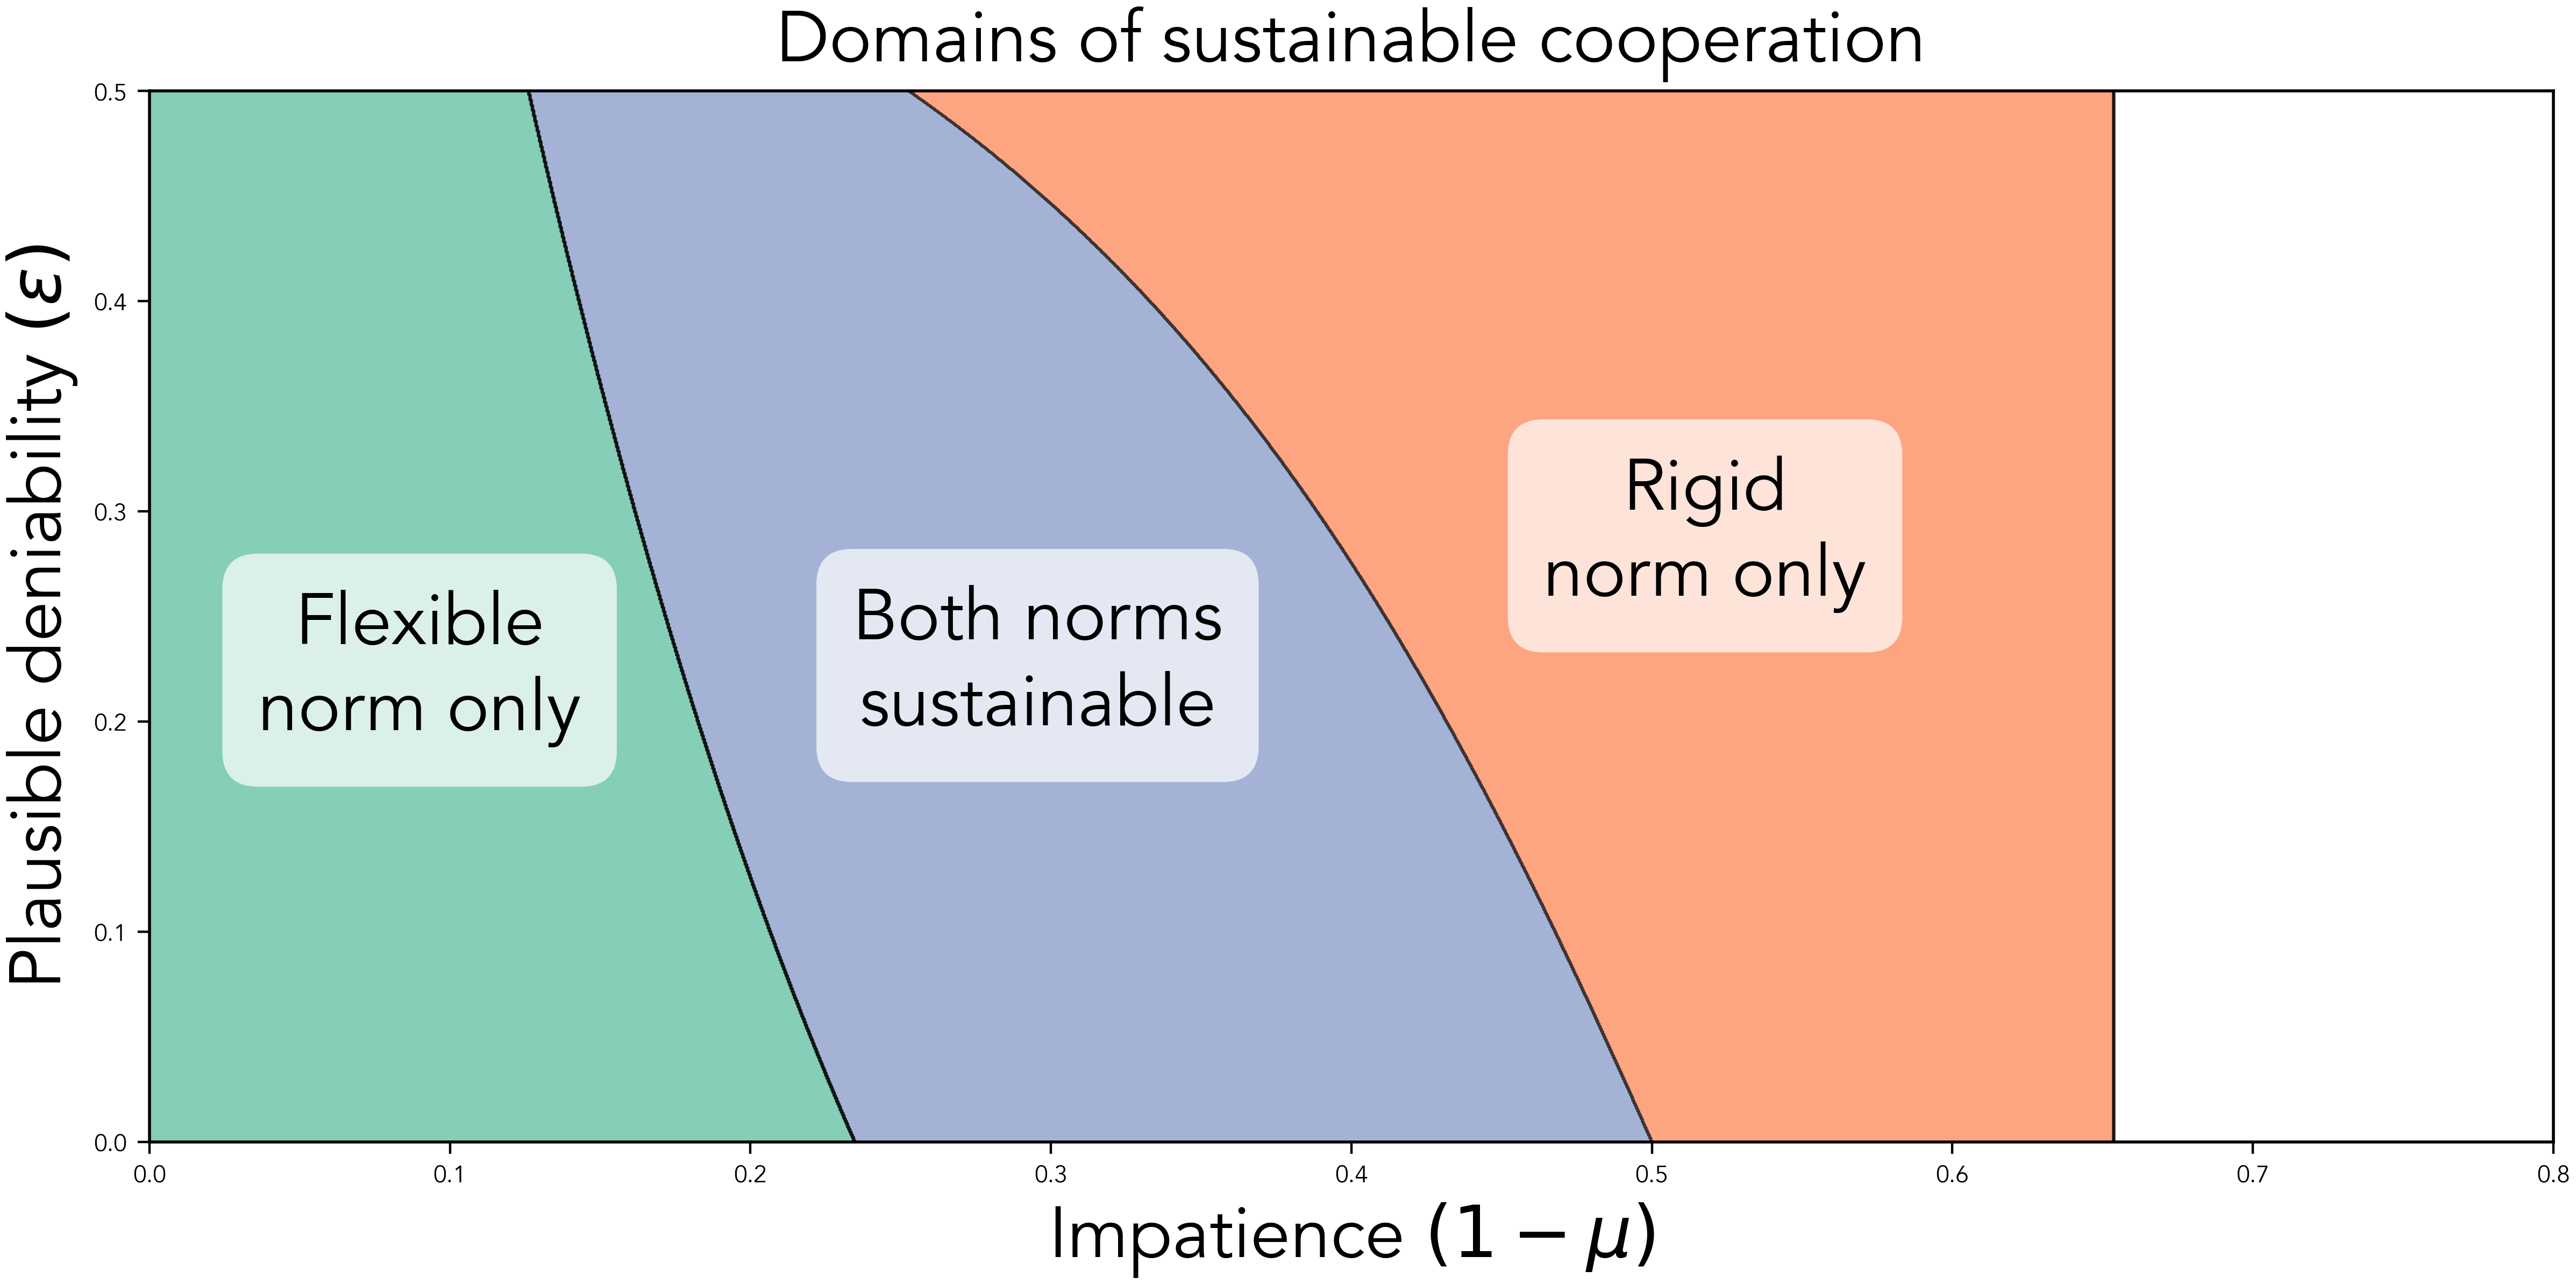

In [50]:
# Make (and possibly save) figure 2:
fig2, ax2 = make_figure_2(
    p=0.2, gamma=0.5, gamma_H=2.0, c=1.0, b=2.0, sigma=0.3,
    max_impatience=0.8,            # crop at x = 0.8
    max_epsilon=0.5,                # 1 - gamma/c
    resolution=2000,                # Set at 2000 for publication figures, 50 enough for testing
    # save_svg="2. new Domains.svg" , save_png="2. Domains.png", save_pdf="2. Domains.pdf"
)

Opportunism prevented: min = 0.0 max = 0.19661556852246895
Efficiency cost: min = 0.33380218240572995 max = 0.7081369093221442


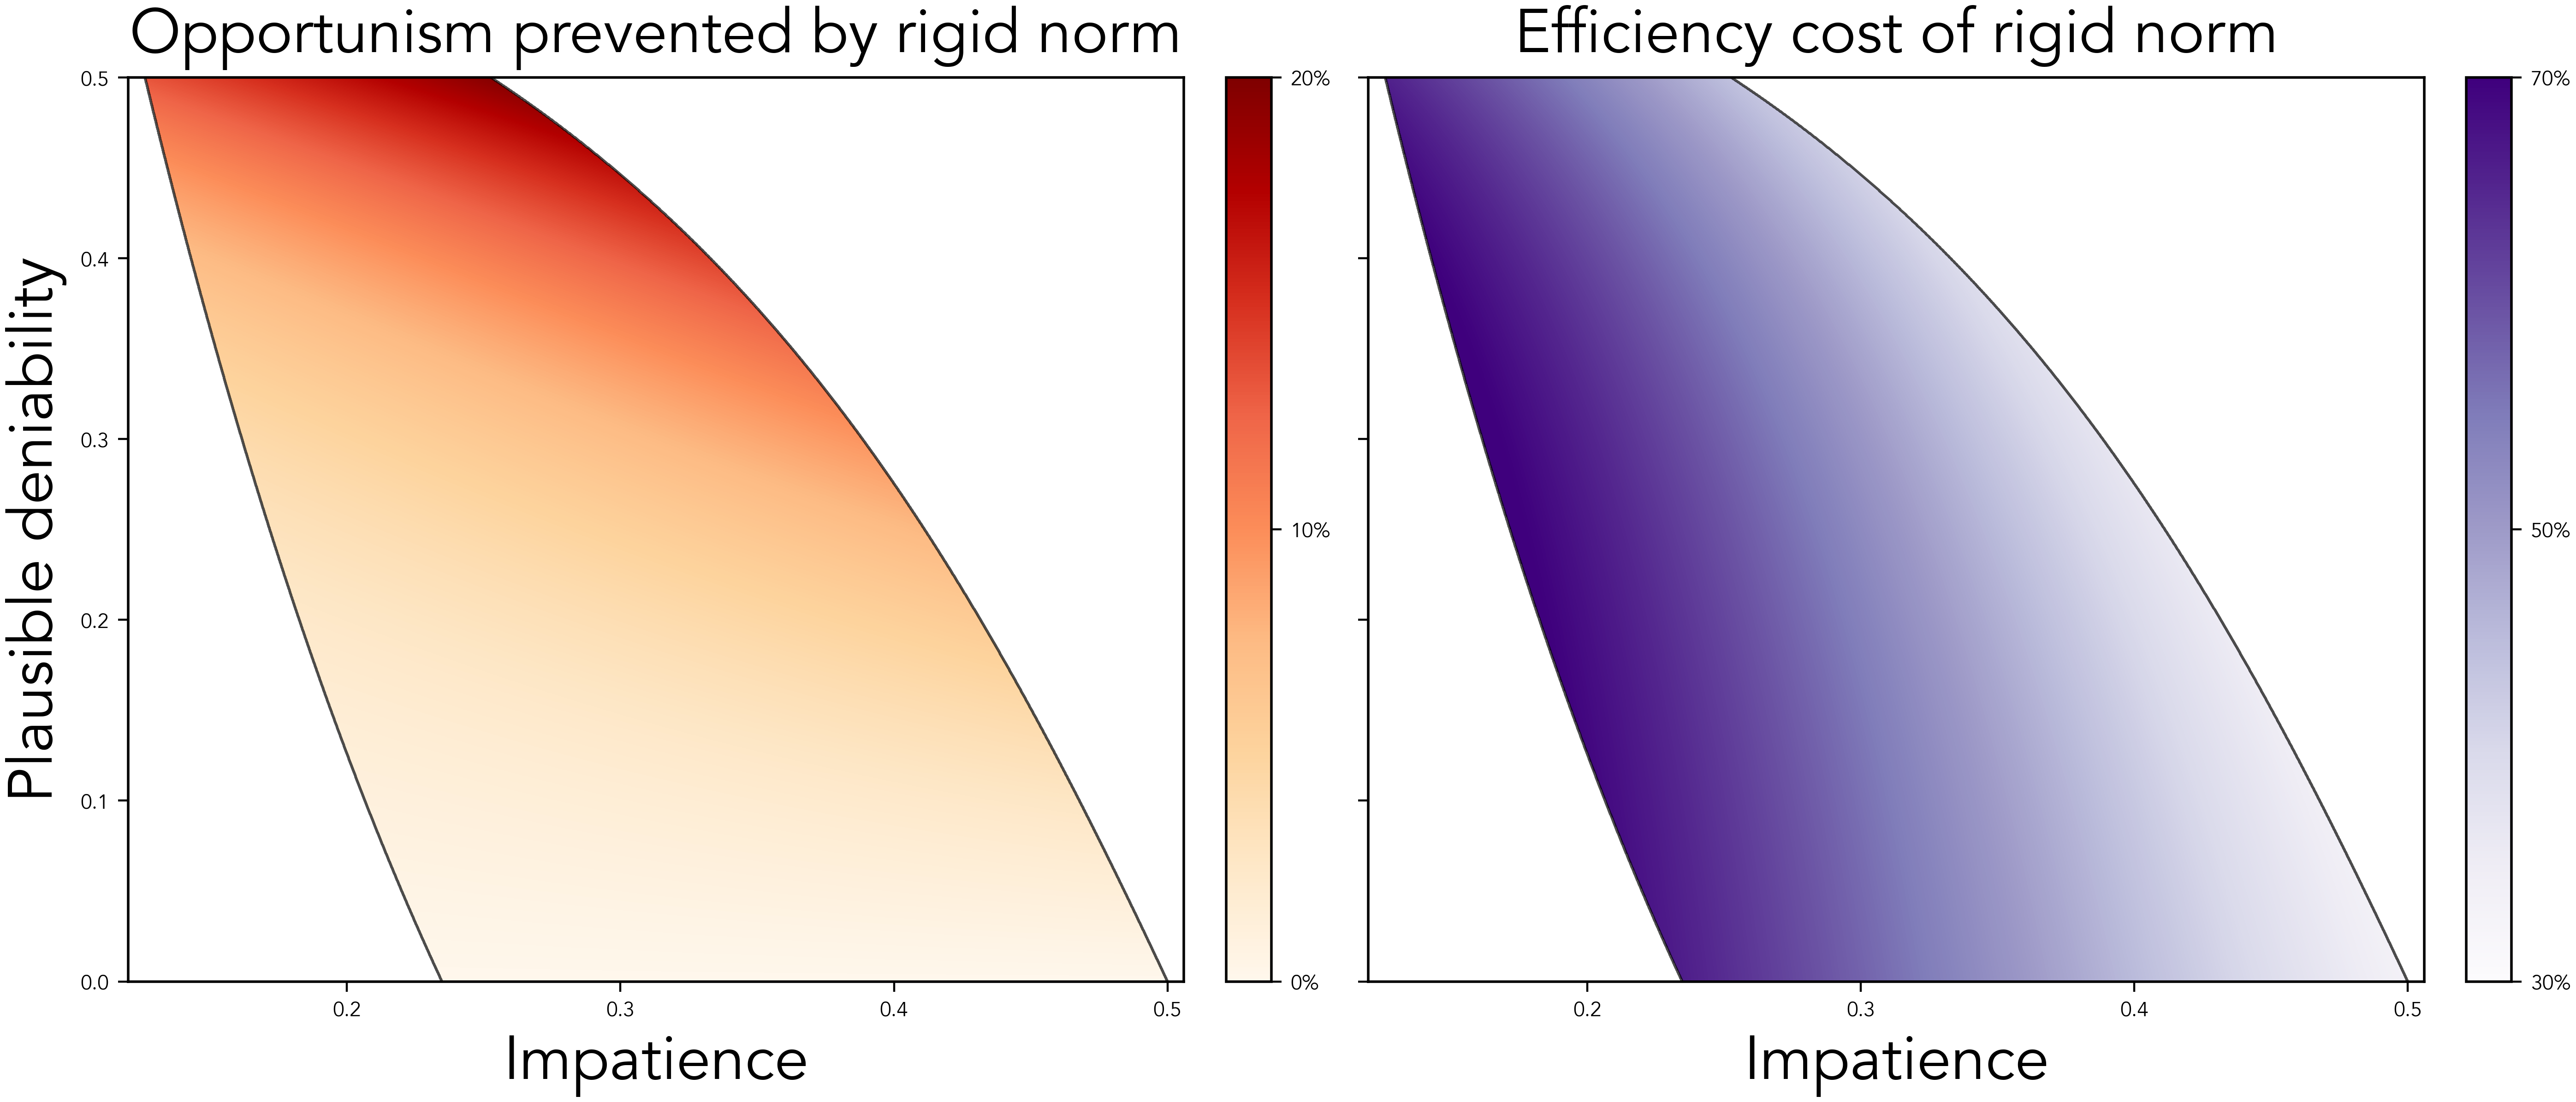

In [46]:
# Make (and possibly save) figure 3:
fig3, axes3 = make_figure_3(
    p=0.2, gamma=0.5, gamma_H=2.0, c=1.0, b=2.0, beta=0.75, sigma=0.3,
    resolution=2000,                           # Set at 2000 for publication figures, 50 enough for testing
    min_impatience=0.12, max_impatience=0.506, # 0.06 padding on each side
    min_epsilon=0.0, max_epsilon=0.50,         # 1 - gamma/c
    figsize=(14, 6),
    vmin_oppo=0.0, vmax_oppo=0.20,             # Range for opportunism prevented
    vmin_eff=0.3,  vmax_eff=0.7,               # Range for payoff loss
    # save_svg="3. Comparison.svg", save_png="3. Comparison.png", save_pdf="3. Comparison.pdf"
)

## 6. Supplementary Figure

Code for generating Supplementary Figure 2

In [47]:
def absolute_efficiency_cost(p, epsilon, gamma, gamma_H, beta, c, b, mu, sigma, cdf=None):
    """Non-normalized efficiency cost of adopting rigid norm."""    
    
    # --- Distribution of types ---
    if cdf is None:
        cdf = truncated_normal_cdf(mu, sigma)

    # --- Make sure both norms exist ---
    both_exist = domain_rigid(p, epsilon, gamma, gamma_H, c, b, mu, sigma, cdf=cdf) \
         and domain_flexible(p, epsilon, gamma, gamma_H, c, b, mu, sigma, cdf=cdf)
    if not both_exist:
        return float('nan')

    # --- Expected PGG payoff ---
    # Flexible norm: no contributions under hardship
    thr               = threshold_contribution_normal_flexible(gamma, c, b, epsilon)
    frac_contrib      = 1 - cdf(thr)
    payoff_flex       = (1 - p) * frac_contrib * (beta - gamma)

    # Rigid norm: contributions under hardship and normal conditions
    thr_norm          = threshold_contribution_normal_rigid(gamma, c, b)
    thr_hard          = threshold_contribution_hardship_rigid(gamma_H, c, b)
    frac_contrib_norm = 1 - cdf(thr_norm)
    frac_contrib_hard = 1 - cdf(thr_hard)
    payoff_rigid      = (1 - p) * frac_contrib_norm * (beta - gamma) + p * frac_contrib_hard * (beta - gamma_H)

    return payoff_flex - payoff_rigid # In contrast to efficiency_cost(), do not divide by (1-p) (beta-gamma), which is negative when beta=0.0

def make_si_figure_2(
    p, gamma, gamma_H, c, b, sigma,
    beta_left=0.75, beta_right=0.0,
    resolution=500,
    min_impatience=0.12, max_impatience=0.506,
    min_epsilon=0.0, max_epsilon=None,
    figsize=(14, 6.5),
    vmin_eff=0.0, vmax_eff=None,
    save_svg=None, save_pdf=None, save_png=None,
):
    _set_plot_style()
 
    if max_epsilon is None:
        max_epsilon = 1 - gamma / c
 
    x_vals = np.linspace(min_impatience, max_impatience, resolution)
    y_vals = np.linspace(min_epsilon, max_epsilon, resolution)
 
    Z_left  = np.full((resolution, resolution), np.nan)
    Z_right = np.full((resolution, resolution), np.nan)
 
    for i, x in enumerate(x_vals):
        mu_x = 1 - x
        cdf = truncated_normal_cdf(mu_x, sigma)
        for j, y in enumerate(y_vals):
            Z_left[j, i]  = absolute_efficiency_cost(
                p, y, gamma, gamma_H, beta_left, c, b, mu_x, sigma, cdf=cdf)
            Z_right[j, i] = absolute_efficiency_cost(
                p, y, gamma, gamma_H, beta_right, c, b, mu_x, sigma, cdf=cdf)
 
    all_vals = np.concatenate([Z_left[~np.isnan(Z_left)],
                               Z_right[~np.isnan(Z_right)]])
    if vmax_eff is None:
        vmax_eff = np.nanmax(all_vals) * 1.02
 
    print(f"beta={beta_left}: range [{np.nanmin(Z_left):.4f}, {np.nanmax(Z_left):.4f}]")
    print(f"beta={beta_right}: range [{np.nanmin(Z_right):.4f}, {np.nanmax(Z_right):.4f}]")
    print(f"Shared colorbar: [{vmin_eff:.4f}, {vmax_eff:.4f}]")
 
    MASK_L = ~np.isnan(Z_left)
    MASK_R = ~np.isnan(Z_right)
 
    fig, (axL, axR) = plt.subplots(1, 2, figsize=figsize, sharey=True)
    cmap = _cmap_payoff()


    for ax, Z, MASK, beta_val, panel_tag, subtitle in [
        (axL, Z_left,  MASK_L, beta_left,  "a",
         f"Cooperative signal ($\\beta = {beta_left} > \\gamma$)"),
        (axR, Z_right, MASK_R, beta_right, "b",
         f"Money-burning signal ($\\beta = {beta_right} < \\gamma$)"),
    ]:
        im = ax.imshow(
            Z, origin="lower",
            extent=(min_impatience, max_impatience, min_epsilon, max_epsilon),
            aspect="auto", cmap=cmap, vmin=vmin_eff, vmax=vmax_eff,
            interpolation="bilinear",
        )
        ax.contour(
            x_vals, y_vals, MASK.astype(float),
            levels=[0.5], colors="black", linewidths=1.0, alpha=0.7,
        )
 
        # Subtitle above each panel
        ax.set_title(subtitle)
 
        ax.set_xlabel(r"Impatience $(1 - \mu)$")
 
        for side in ["left", "right", "top", "bottom"]:
            ax.spines[side].set_visible(True)
            ax.spines[side].set_linewidth(1.0)
        ax.grid(False)
        ax.set_xlim(min_impatience, max_impatience)
        ax.set_ylim(min_epsilon, max_epsilon)
        ax.xaxis.set_major_locator(MultipleLocator(0.1))
        ax.yaxis.set_major_locator(MultipleLocator(0.1))
  
    axL.set_ylabel(r"Plausible deniability $(\varepsilon)$")
    axL.tick_params(axis="y", labelleft=True)
    axR.tick_params(axis="y", labelleft=False)
 
    # Shared colorbar
    cbar = fig.colorbar(im, ax=[axL, axR], fraction=0.03, pad=0.04)
    #cbar.set_label(r"$\pi^{\mathrm{flex}} - \pi^{\mathrm{rigid}}$",)
 
    if save_svg: fig.savefig(save_svg)
    if save_pdf: fig.savefig(save_pdf)
    if save_png: fig.savefig(save_png, dpi=400)
    return fig, (axL, axR) 

beta=0.75: range [0.0668, 0.1416]
beta=0.0: range [0.1069, 0.3059]
Shared colorbar: [0.0000, 0.3120]


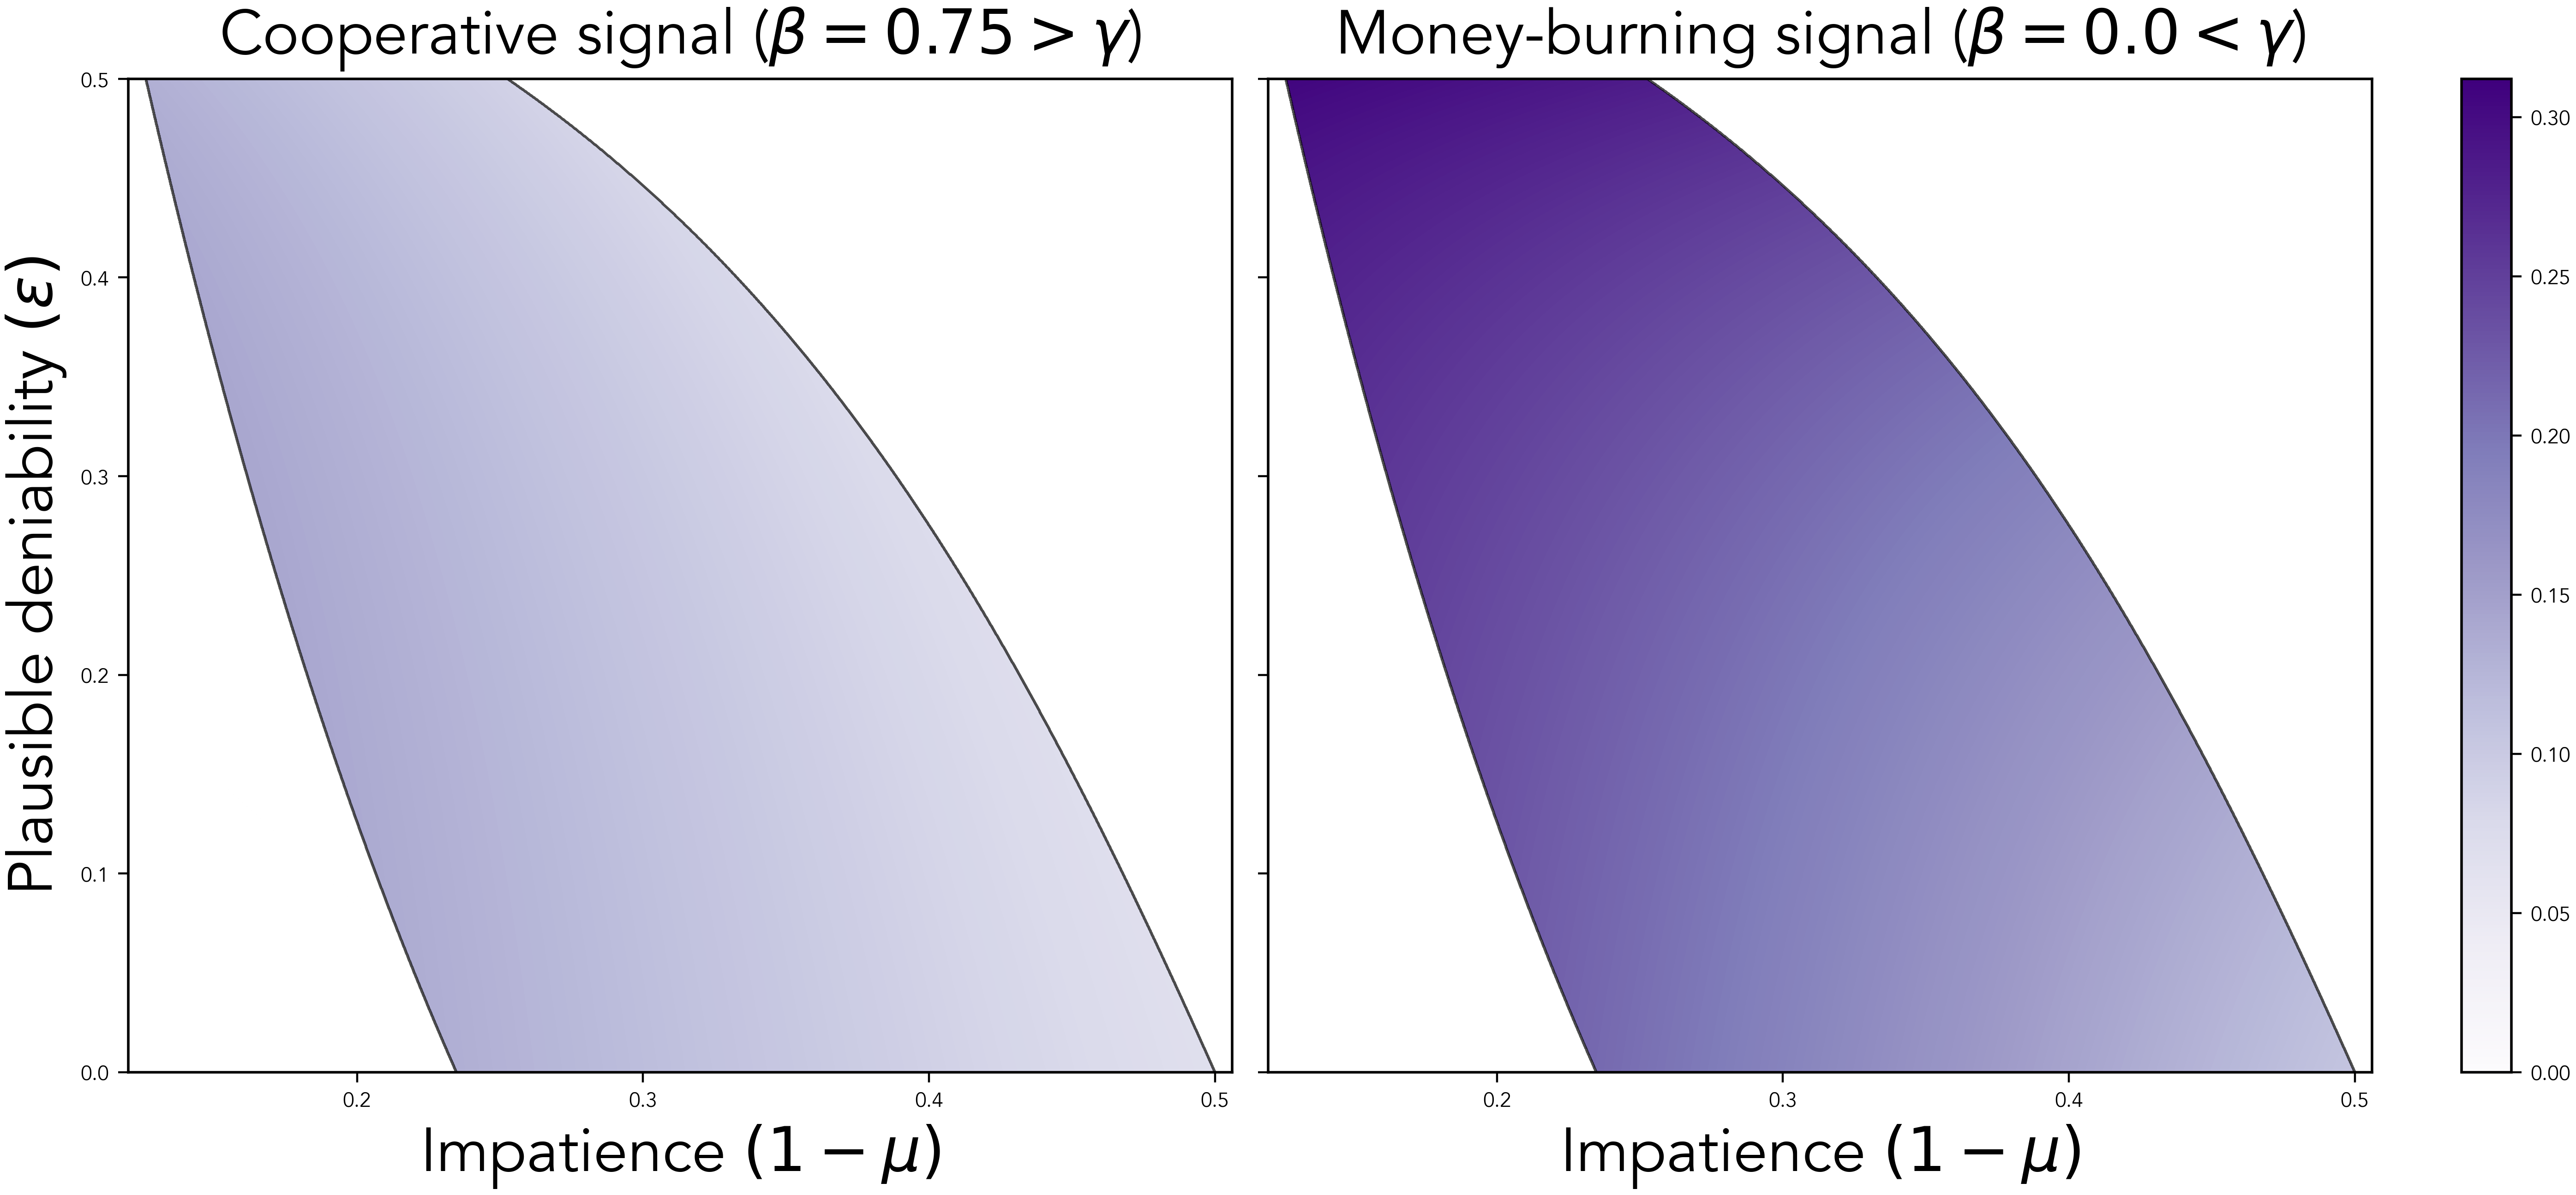

In [51]:
# Make (and possibly save) SI figure 2
fig_si, axes_si = make_si_figure_2(
    p=0.2, gamma=0.5, gamma_H=2.0, c=1.0, b=2.0, sigma=0.3,
    beta_left=0.75, beta_right=0.0,
    resolution=2000, # Set at 2000 for publication figures, 50 enough for testing
    #save_pdf="fig_si_efficiency.pdf",
    #save_png="fig_si_efficiency.png",
)
